In [7]:
import httpx
import pendulum
import polars as pl
import scipy.stats
import numpy as np
# from hishel.httpx import SyncCacheClient
from hishel import CacheClient as SyncCacheClient
import matplotlib.pyplot as plt

from liblaf import grapes
from pendulum import DateTime

from qoc.market import MarketDataFuturesUsds

In [8]:
METRIC_NAMES: list[str] = [
    "daa",
    "fdv",
    "fees",
    "market_cap",
    "profit",
    "rent_paid",
    "stables_mcap",
    "throughput",
    "tvl",
    "txcosts",
    "txcount",
]
ORIGIN_KEY_TO_SYMBOL: dict[str, str] = {
    "arbitrum": "ARBUSDT",
    "base": "ETHUSDT",
    "celo": "CELOUSDT",
    "ethereum": "ETHUSDT",
    "fraxtal": "FXSUSDT",
    "gravity": "GUSDT",
    "imx": "IMXUSDT",
    "lisk": "LSKUSDT",
    "manta": "MANTAUSDT",
    "metis": "METISUSDT",
    "optimism": "OPUSDT",
    "plume": "PLUMEUSDT",
    "polygonzkevm": "POLUSDT",
    "scroll": "SCRUSDT",
    "starknet": "STRKUSDT",
    "taiko": "TAIKOUSDT",
    "unichain": "UNIUSDT",
    "worldchain": "WLDUSDT",
    "zksyncera": "ZKUSDT",
}
start: DateTime = pendulum.datetime(2023, 1, 1)
end: DateTime = pendulum.datetime(2025, 12, 1)

In [9]:
client = SyncCacheClient()
data: pl.DataFrame = pl.DataFrame()
metric_names: list[str] = []
for metric_key in METRIC_NAMES:
    response: httpx.Response = client.get(
        f"https://api.growthepie.com/v1/export/{metric_key}.json",
    )
    metric: pl.DataFrame = pl.from_records(response.json()).cast({"date": pl.Date()})
    metric = metric.sort(pl.col("date")).filter(
        pl.col("date").is_between(start.date(), end.date())
    )
    metric_names += metric["metric_key"].unique().to_list()
    metric = metric.with_columns(
        pl.concat_str(pl.col("origin_key"), pl.col("metric_key"), separator="_").alias(
            "origin_metric"
        )
    ).pivot("origin_metric", index="date", values="value")
    data = (
        metric
        if data.is_empty()
        else data.join(metric, on="date", how="full", validate="1:1", coalesce=True)
    )

In [10]:
data.write_csv("growthepie_metrics.csv")

In [11]:
metric

date,imx_txcount,loopring_txcount,polygon_pos_txcount,starknet_txcount,optimism_txcount,arbitrum_txcount,ethereum_txcount,metis_txcount,arbitrum_nova_txcount,celo_txcount,zksync_era_txcount,base_txcount,zora_txcount,mantle_txcount,linea_txcount,manta_txcount,scroll_txcount,orderly_txcount,derive_txcount,mode_txcount,fraxtal_txcount,blast_txcount,redstone_txcount,lisk_txcount,gravity_txcount,taiko_txcount,worldchain_txcount,unichain_txcount,swell_txcount,soneium_txcount,ink_txcount,plume_txcount,megaeth_txcount
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01,156132.0,5250.0,2.609478e6,7109.0,376651.0,158731.0,742785.0,2981.0,7465.0,483514.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2023-01-02,182626.0,9306.0,2.77486e6,10055.0,396881.0,203740.0,920276.0,4102.0,8574.0,471016.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2023-01-03,193021.0,4708.0,3.047194e6,13414.0,504789.0,289056.0,948116.0,4040.0,9690.0,509949.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2023-01-04,264360.0,8798.0,3.094178e6,20740.0,525197.0,365768.0,1.046389e6,5723.0,10403.0,505643.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2023-01-05,855975.0,6583.0,3.10929e6,19636.0,511981.0,244090.0,1.142818e6,4292.0,9962.0,457275.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-11-27,48822.0,35.0,6.04622e6,282051.0,1.257211e6,2.798686e6,1.892795e6,22147.0,3623.0,1.414954e6,19023.0,1.565354e7,4602.0,30038.0,110467.0,47089.0,64299.0,11650.0,15973.0,167822.0,16323.0,310740.0,4869.0,60914.0,410857.0,26294.0,1.93563e6,577387.0,23024.0,1.183951e6,645431.0,115987.0,1853.0
2025-11-28,61983.0,68.0,5.900981e6,250289.0,1.706067e6,2.464426e6,1.689025e6,28623.0,3442.0,1.385194e6,20086.0,1.3754918e7,4677.0,27422.0,115712.0,45542.0,74653.0,13129.0,19650.0,161666.0,11767.0,308286.0,497.0,68496.0,338077.0,27574.0,1.992265e6,730817.0,23717.0,1.242621e6,687700.0,112281.0,2246.0
2025-11-29,67967.0,68.0,5.336057e6,231099.0,1.164545e6,2.254097e6,1.364687e6,19976.0,2821.0,1.298371e6,18161.0,1.2761149e7,3845.0,29628.0,92097.0,40242.0,57088.0,10363.0,19205.0,144034.0,10875.0,220668.0,270.0,74895.0,417701.0,24349.0,1.921742e6,639111.0,23550.0,1.172108e6,616681.0,109929.0,5061.0


In [12]:
market_data = MarketDataFuturesUsds()
for origin_key, symbol in ORIGIN_KEY_TO_SYMBOL.items():
    print(f"Processing {origin_key} - {symbol}")
    klines: pl.DataFrame = market_data.klines(symbol, "1d", start=start, end=end)
    klines = klines.select(
        pl.col("close").alias(f"{origin_key}_price"),
        pl.col("open_time").dt.date().alias("date"),
    )
    
    # 对 klines 按日期去重，保留最后一条记录
    klines = klines.unique(subset=["date"], keep="last")
    
    # 对 data 按日期去重（如果有重复的话）
    data = data.unique(subset=["date"], keep="last")
    
    data = data.join(klines, on="date", how="full", coalesce=True)

Processing arbitrum - ARBUSDT
Processing base - ETHUSDT
Processing celo - CELOUSDT
Processing ethereum - ETHUSDT
Processing fraxtal - FXSUSDT
Processing gravity - GUSDT
Processing imx - IMXUSDT
Processing lisk - LSKUSDT
Processing manta - MANTAUSDT
Processing metis - METISUSDT
Processing optimism - OPUSDT
Processing plume - PLUMEUSDT
Processing polygonzkevm - POLUSDT
Processing scroll - SCRUSDT
Processing starknet - STRKUSDT
Processing taiko - TAIKOUSDT
Processing unichain - UNIUSDT
Processing worldchain - WLDUSDT
Processing zksyncera - ZKUSDT


In [13]:
data.columns

['date',
 'imx_daa',
 'loopring_daa',
 'optimism_daa',
 'arbitrum_daa',
 'ethereum_daa',
 'metis_daa',
 'arbitrum_nova_daa',
 'celo_daa',
 'polygon_pos_daa',
 'starknet_daa',
 'zksync_era_daa',
 'base_daa',
 'zora_daa',
 'mantle_daa',
 'linea_daa',
 'manta_daa',
 'orderly_daa',
 'scroll_daa',
 'derive_daa',
 'mode_daa',
 'fraxtal_daa',
 'blast_daa',
 'redstone_daa',
 'lisk_daa',
 'gravity_daa',
 'taiko_daa',
 'worldchain_daa',
 'unichain_daa',
 'swell_daa',
 'soneium_daa',
 'ink_daa',
 'plume_daa',
 'megaeth_daa',
 'metis_fdv_eth',
 'optimism_fdv_usd',
 'loopring_fdv_usd',
 'polygon_pos_fdv_eth',
 'ethereum_fdv_usd',
 'polygon_pos_fdv_usd',
 'metis_fdv_usd',
 'celo_fdv_usd',
 'imx_fdv_usd',
 'celo_fdv_eth',
 'imx_fdv_eth',
 'optimism_fdv_eth',
 'loopring_fdv_eth',
 'ethereum_fdv_eth',
 'arbitrum_fdv_usd',
 'arbitrum_fdv_eth',
 'mantle_fdv_usd',
 'mantle_fdv_eth',
 'worldchain_fdv_eth',
 'worldchain_fdv_usd',
 'fraxtal_fdv_usd',
 'fraxtal_fdv_eth',
 'lisk_fdv_usd',
 'lisk_fdv_eth',
 'ma

In [14]:
new_metric_names = []

for name in data.columns:
  first_after = name.split("_", 1)[1] if "_" in name else None
  if first_after and first_after not in new_metric_names:
    new_metric_names.append(first_after)

In [15]:
new_metric_names

['daa',
 'nova_daa',
 'pos_daa',
 'era_daa',
 'fdv_eth',
 'fdv_usd',
 'pos_fdv_eth',
 'pos_fdv_usd',
 'era_fdv_usd',
 'era_fdv_eth',
 'fees_paid_eth',
 'pos_fees_paid_eth',
 'fees_paid_usd',
 'nova_fees_paid_eth',
 'nova_fees_paid_usd',
 'pos_fees_paid_usd',
 'era_fees_paid_eth',
 'era_fees_paid_usd',
 'market_cap_usd',
 'market_cap_eth',
 'pos_market_cap_usd',
 'pos_market_cap_eth',
 'era_market_cap_usd',
 'era_market_cap_eth',
 'profit_usd',
 'pos_profit_usd',
 'profit_eth',
 'pos_profit_eth',
 'era_profit_usd',
 'era_profit_eth',
 'rent_paid_usd',
 'pos_rent_paid_usd',
 'rent_paid_eth',
 'pos_rent_paid_eth',
 'nova_rent_paid_usd',
 'nova_rent_paid_eth',
 'era_rent_paid_usd',
 'era_rent_paid_eth',
 'stables_mcap_eth',
 'pos_stables_mcap',
 'stables_mcap',
 'era_stables_mcap',
 'nova_stables_mcap',
 'pos_stables_mcap_eth',
 'nova_stables_mcap_eth',
 'era_stables_mcap_eth',
 'pos_gas_per_second',
 'gas_per_second',
 'nova_gas_per_second',
 'tvl_eth',
 'tvl',
 'pos_tvl',
 'nova_tvl',
 '

In [16]:
new_metric_names = [name for name in new_metric_names if "price" not in name]

## Clone

In [44]:
data_copy = data.clone()

In [45]:
# origin_key: str = "imx"
# metric_key: str = "daa"
price_shift: int = 90
metric_shift: int = 15


for metric_key in new_metric_names:
    print(f"--------- Analyzing Metric: {metric_key} ---------")
    for origin_key in ORIGIN_KEY_TO_SYMBOL.keys():        

        price_key: str = f"{origin_key}_price"
        origin_metric_key: str = f"{origin_key}_{metric_key}"
        if origin_metric_key not in data.columns:
            continue

        # 修正：使用 Polars 的 log 函数
        log_price = pl.col(price_key)
        # log_price = pl.col(price_key).log()
        log_metric = pl.col(origin_metric_key).log()

        valid_data: pl.DataFrame = data.select(
            pl.col("date"),
            (
                (log_price.shift(-price_shift - 1) - log_price.shift(-1))
                # 注意：这里除法可能有问题，对数差值不应该再除以 log_price
            ).alias(f"{price_key}_{price_shift}d_change"),
            (
                (
                    log_metric.shift(1)
                    - log_metric.shift(metric_shift + 1)
                )
                / log_metric.shift(metric_shift + 1)
            ).alias(f"{origin_metric_key}_{metric_shift}d_change"),
        ).drop_nulls()
        if len(valid_data) < 50:  # 数据点太少就跳过
            continue
        corr_coef, p_value = scipy.stats.pearsonr(
            valid_data[f"{price_key}_{price_shift}d_change"].to_list(),
            valid_data[f"{origin_metric_key}_{metric_shift}d_change"].to_list(),
        )
        print(
            f"Origin: {origin_key}, Metric: {metric_key}, Correlation Coefficient: {corr_coef:.4f}, P-value: {p_value:.4f}"
        )
        
        # if metric_key=='txcosts_median_usd':
        #     plt.figure(figsize=(12, 8))
            
        #     # 获取原始的对数数据
        #     plot_data = data.select(
        #         pl.col("date"),
        #         pl.col(price_key).log().alias("log_price"),
        #         pl.col(origin_metric_key).log().alias("log_metric")
        #     ).drop_nulls().sort("date")
            
        #     dates = plot_data["date"].to_numpy()
        #     log_price_vals = plot_data["log_price"].to_numpy()
        #     log_metric_vals = plot_data["log_metric"].to_numpy()
            
        #     # 创建双轴图
        #     fig, ax1 = plt.subplots(figsize=(12, 8))
        #     ax2 = ax1.twinx()
            
        #     # 左轴：对数指标
        #     line1 = ax1.plot(dates, log_metric_vals, 'b-', alpha=0.7, linewidth=2, label=f"Log {metric_key}")
        #     ax1.set_xlabel("Date")
        #     ax1.set_ylabel(f"Log {metric_key}", color='blue')
        #     ax1.tick_params(axis='y', labelcolor='blue')
            
        #     # 右轴：对数价格
        #     line2 = ax2.plot(dates, log_price_vals, 'r-', alpha=0.7, linewidth=2, label="Log Price")
        #     ax2.set_ylabel("Log Price", color='red')
        #     ax2.tick_params(axis='y', labelcolor='red')
            
        #     # 设置标题
        #     plt.title(f"Time Series: {origin_key} Log {metric_key} vs Log Price\nCorr={corr_coef:.4f}, p={p_value:.4f}")
            
        #     # 网格
        #     ax1.grid(True, alpha=0.3)
            
        #     # 合并图例
        #     lines = line1 + line2
        #     labels = [l.get_label() for l in lines]
        #     ax1.legend(lines, labels, loc='upper left')
            
        #     # 旋转日期标签以避免重叠
        #     plt.xticks(rotation=45)
        #     plt.tight_layout()
        #     plt.show()
        #     plt.close()

--------- Analyzing Metric: daa ---------
Origin: arbitrum, Metric: daa, Correlation Coefficient: 0.0004, P-value: 0.9900
Origin: base, Metric: daa, Correlation Coefficient: nan, P-value: nan
Origin: celo, Metric: daa, Correlation Coefficient: -0.0092, P-value: 0.7754
Origin: ethereum, Metric: daa, Correlation Coefficient: 0.0601, P-value: 0.0627
Origin: fraxtal, Metric: daa, Correlation Coefficient: nan, P-value: nan
Origin: gravity, Metric: daa, Correlation Coefficient: -0.0406, P-value: 0.7664
Origin: imx, Metric: daa, Correlation Coefficient: 0.0099, P-value: 0.7594
Origin: lisk, Metric: daa, Correlation Coefficient: nan, P-value: nan
Origin: manta, Metric: daa, Correlation Coefficient: -0.0081, P-value: 0.9020
Origin: metis, Metric: daa, Correlation Coefficient: 0.0467, P-value: 0.3919
Origin: optimism, Metric: daa, Correlation Coefficient: 0.0066, P-value: 0.8394
Origin: scroll, Metric: daa, Correlation Coefficient: 0.1940, P-value: 0.0909
Origin: starknet, Metric: daa, Correlati

In [46]:
data

date,imx_daa,loopring_daa,optimism_daa,arbitrum_daa,ethereum_daa,metis_daa,arbitrum_nova_daa,celo_daa,polygon_pos_daa,starknet_daa,zksync_era_daa,base_daa,zora_daa,mantle_daa,linea_daa,manta_daa,orderly_daa,scroll_daa,derive_daa,mode_daa,fraxtal_daa,blast_daa,redstone_daa,lisk_daa,gravity_daa,taiko_daa,worldchain_daa,unichain_daa,swell_daa,soneium_daa,ink_daa,plume_daa,megaeth_daa,metis_fdv_eth,optimism_fdv_usd,loopring_fdv_usd,…,manta_txcount,scroll_txcount,orderly_txcount,derive_txcount,mode_txcount,fraxtal_txcount,blast_txcount,redstone_txcount,lisk_txcount,gravity_txcount,taiko_txcount,worldchain_txcount,unichain_txcount,swell_txcount,soneium_txcount,ink_txcount,plume_txcount,megaeth_txcount,arbitrum_price,base_price,celo_price,ethereum_price,fraxtal_price,gravity_price,imx_price,lisk_price,manta_price,metis_price,optimism_price,plume_price,polygonzkevm_price,scroll_price,starknet_price,taiko_price,unichain_price,worldchain_price,zksyncera_price
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-09-22,1223.0,16.0,91263.0,291179.0,485063.0,9803.0,712.0,666916.0,547423.0,53181.0,13661.0,800712.0,1869.0,82889.0,57511.0,16726.0,33.0,5807.0,26.0,1389.0,424.0,2909.0,118.0,16033.0,231768.0,14921.0,67034.0,18086.0,272.0,48024.0,63153.0,55886.0,null,33691.473296,3.3516e9,1.2555e8,…,102286.0,106411.0,24932.0,10726.0,241789.0,20972.0,349886.0,11548.0,105033.0,667429.0,177908.0,1.830849e6,1.42846e6,44021.0,2.701012e6,735038.0,268647.0,null,0.4362,4196.86,0.271,4196.86,2.449,0.01017,0.6839,0.3212,0.1862,13.38,0.7032,0.10198,0.22721,0.2776,0.1189,0.3736,8.226,1.3922,0.05042
2023-03-02,7425.0,784.0,35804.0,112720.0,382609.0,1072.0,5062.0,10001.0,351489.0,4982.0,533.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,105054.807087,1.1868e10,5.0088e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1647.29,0.751,1647.29,11.095,null,0.9888,null,null,null,2.7208,null,null,null,null,null,6.634,null,null
2025-09-28,1406.0,24.0,48923.0,366978.0,436336.0,5894.0,2202.0,679933.0,685947.0,53682.0,10659.0,940425.0,4309.0,5924.0,32844.0,13471.0,33.0,5498.0,27.0,1297.0,446.0,2575.0,116.0,17807.0,243251.0,13890.0,67838.0,15142.0,301.0,73527.0,64556.0,36458.0,null,33162.688747,2.8928e9,1.1402e8,…,74077.0,90763.0,14635.0,10801.0,267011.0,26351.0,361778.0,12633.0,83003.0,566405.0,141338.0,1.820118e6,746108.0,61024.0,1.490653e6,649233.0,181557.0,null,0.4299,4139.55,0.254,4139.55,2.1251,0.0101,0.7947,0.3088,0.1818,13.48,0.6822,0.10229,0.22837,0.2875,0.1232,0.3565,7.746,1.3294,0.05063
2023-07-02,5854.0,826.0,81479.0,156149.0,285850.0,4256.0,11152.0,58781.0,365006.0,68639.0,197206.0,null,5931.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,58201.257642,5.7906e9,3.2615e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.1509,1937.69,0.542,1937.69,5.818,null,0.7553,null,null,null,1.333,null,null,null,null,null,5.566,null,null
2023-04-01,10543.0,1178.0,43845.0,132430.0,357749.0,785.0,13973.0,11623.0,415614.0,35603.0,70023.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,73649.711286,9.8243e9,4.9619e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.2928,1819.82,0.669,1819.82,8.786,null,1.1109,null,null,null,2.2771,null,null,null,null,null,6.096,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023-10-17,4876.0,386.0,63688.0,108998.0,322095.0,1151.0,9287.0,118725.0,341908.0,146733.0,247746.0,105884

In [47]:

start: DateTime = pendulum.datetime(2023, 1, 1)
end: DateTime = pendulum.datetime(2025, 1, 1)
data_copy = data_copy.filter(pl.col("date").is_between(start.date(), end.date()))
data_copy

date,imx_daa,loopring_daa,optimism_daa,arbitrum_daa,ethereum_daa,metis_daa,arbitrum_nova_daa,celo_daa,polygon_pos_daa,starknet_daa,zksync_era_daa,base_daa,zora_daa,mantle_daa,linea_daa,manta_daa,orderly_daa,scroll_daa,derive_daa,mode_daa,fraxtal_daa,blast_daa,redstone_daa,lisk_daa,gravity_daa,taiko_daa,worldchain_daa,unichain_daa,swell_daa,soneium_daa,ink_daa,plume_daa,megaeth_daa,metis_fdv_eth,optimism_fdv_usd,loopring_fdv_usd,…,manta_txcount,scroll_txcount,orderly_txcount,derive_txcount,mode_txcount,fraxtal_txcount,blast_txcount,redstone_txcount,lisk_txcount,gravity_txcount,taiko_txcount,worldchain_txcount,unichain_txcount,swell_txcount,soneium_txcount,ink_txcount,plume_txcount,megaeth_txcount,arbitrum_price,base_price,celo_price,ethereum_price,fraxtal_price,gravity_price,imx_price,lisk_price,manta_price,metis_price,optimism_price,plume_price,polygonzkevm_price,scroll_price,starknet_price,taiko_price,unichain_price,worldchain_price,zksyncera_price
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-03-02,7425.0,784.0,35804.0,112720.0,382609.0,1072.0,5062.0,10001.0,351489.0,4982.0,533.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,105054.807087,1.1868e10,5.0088e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1647.29,0.751,1647.29,11.095,null,0.9888,null,null,null,2.7208,null,null,null,null,null,6.634,null,null
2023-07-02,5854.0,826.0,81479.0,156149.0,285850.0,4256.0,11152.0,58781.0,365006.0,68639.0,197206.0,null,5931.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,58201.257642,5.7906e9,3.2615e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.1509,1937.69,0.542,1937.69,5.818,null,0.7553,null,null,null,1.333,null,null,null,null,null,5.566,null,null
2023-04-01,10543.0,1178.0,43845.0,132430.0,357749.0,785.0,13973.0,11623.0,415614.0,35603.0,70023.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,73649.711286,9.8243e9,4.9619e8,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.2928,1819.82,0.669,1819.82,8.786,null,1.1109,null,null,null,2.2771,null,null,null,null,null,6.096,null,null
2023-11-25,3943.0,348.0,69593.0,189454.0,307577.0,922.0,6631.0,157920.0,375469.0,231660.0,300089.0,57999.0,17419.0,6401.0,147902.0,14661.0,25.0,31884.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,49566.327341,7.7224e9,2.9789e8,…,64293.0,91390.0,6753.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.067,2082.87,0.557,2082.87,7.407,null,1.4161,null,null,null,1.7852,null,null,null,null,null,6.168,2.7351,null
2024-12-16,4361.0,204.0,70043.0,412697.0,429085.0,20688.0,1246.0,594654.0,423710.0,6833.0,41853.0,1.141193e6,19427.0,80262.0,69318.0,100552.0,24.0,18376.0,26.0,2661.0,587.0,22820.0,173.0,25864.0,151043.0,274280.0,26424.0,3.0,45.0,29.0,27.0,null,null,141787.649114,1.0921e10,3.6869e8,…,221883.0,79787.0,10901.0,28661.0,71276.0,8165.0,322995.0,15907.0,347591.0,470073.0,3.836657e6,616894.0,1977.0,2269.0,604.0,673.0,null,null,1.0028,3984.76,0.81,3984.76,3.4067,0.03379,1.8047,1.0968,1.0943,57.19,2.4958,null,0.59262,1.2077,0.6277,null,16.229,2.8645,0.2239
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-02-25,4190.0,365.0,103491.0,191091.0,399463.0,5131.0,8056.0,77996.0,1.06616e6,102158.0,505782.0,106705.0,31422.0,12008.0,246879.0,10673.0,29.0,112979.0,18.0,9911.0,5.0,4.0,null,null,null,null,null,null,null,null,null,null,null,328973.789

In [48]:
# txcosts_median_usd

metric_cols = ["date"] + [col for col in data_copy.columns if "txcosts_median_eth" in col]
price_cols = ["date"] + [col for col in data_copy.columns if "price" in col]
data_metric = data_copy.select(metric_cols)
data_price = data_copy.select(price_cols)


# 获取 data_metric 和 data_price 的列名前缀
metric_prefixes = {col.split("_")[0] for col in data_metric.columns if "_" in col}
price_prefixes = {col.split("_")[0] for col in data_price.columns if "_" in col}

# 找到前缀的交集
common_prefixes = metric_prefixes & price_prefixes

# 筛选出前缀有交集的列
filtered_metric_cols = ["date"] + [col for col in data_metric.columns if col.split("_")[0] in common_prefixes]
filtered_price_cols = ["date"] + [col for col in data_price.columns if col.split("_")[0] in common_prefixes]

# 筛选数据
filtered_data_metric = data_metric.select(filtered_metric_cols)
filtered_data_price = data_price.select(filtered_price_cols)

In [49]:
common_prefixes

{'arbitrum',
 'base',
 'celo',
 'ethereum',
 'gravity',
 'lisk',
 'manta',
 'metis',
 'optimism',
 'plume',
 'scroll',
 'starknet',
 'taiko',
 'unichain',
 'worldchain'}

In [50]:
filtered_data_price

date,arbitrum_price,base_price,celo_price,ethereum_price,gravity_price,lisk_price,manta_price,metis_price,optimism_price,plume_price,scroll_price,starknet_price,taiko_price,unichain_price,worldchain_price
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-03-02,null,1647.29,0.751,1647.29,null,null,null,null,2.7208,null,null,null,null,6.634,null
2023-07-02,1.1509,1937.69,0.542,1937.69,null,null,null,null,1.333,null,null,null,null,5.566,null
2023-04-01,1.2928,1819.82,0.669,1819.82,null,null,null,null,2.2771,null,null,null,null,6.096,null
2023-11-25,1.067,2082.87,0.557,2082.87,null,null,null,null,1.7852,null,null,null,null,6.168,2.7351
2024-12-16,1.0028,3984.76,0.81,3984.76,0.03379,1.0968,1.0943,57.19,2.4958,null,1.2077,0.6277,null,16.229,2.8645
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-02-25,1.9067,3115.24,0.929,3115.24,null,1.3585,2.948,null,3.8859,null,null,1.9503,null,11.15,8.5543
2023-05-06,1.2389,1895.29,0.562,1895.29,null,null,null,null,1.8664,null,null,null,null,5.284,null
2024-03-11,2.0862,4070.52,1.768,4070.52,null,2.1715,3.8621,null,4.5911,null,null,2.5916,null,14.459,9.8496


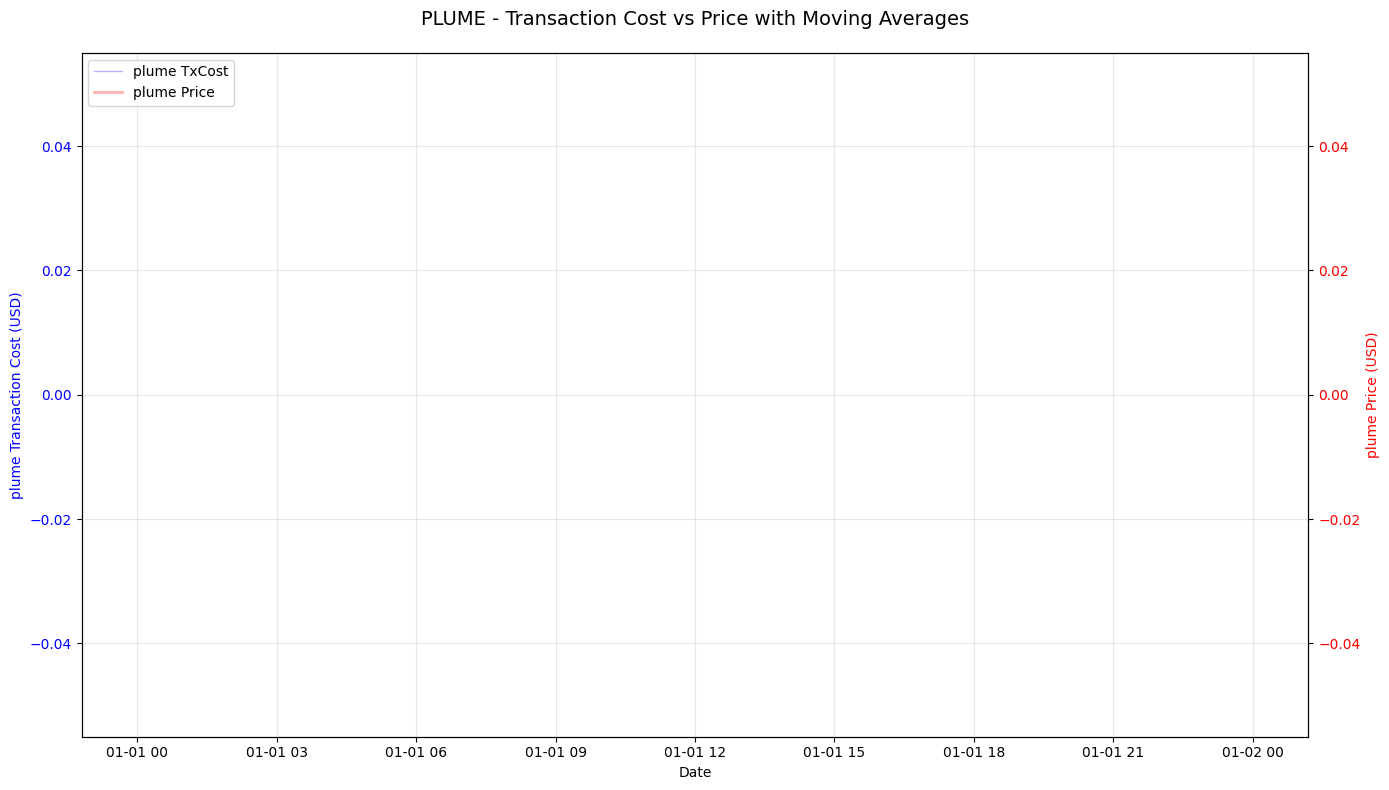

Completed visualization for plume


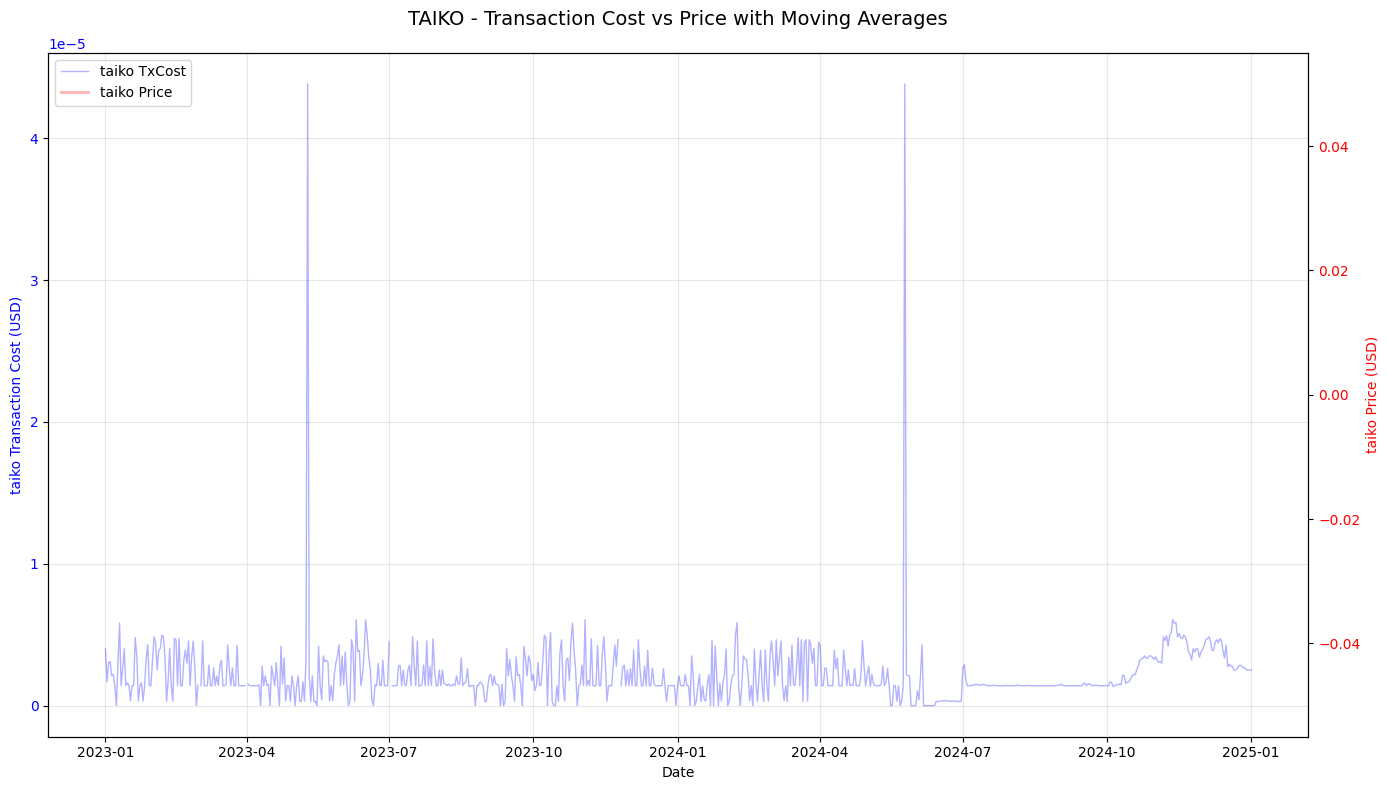

Completed visualization for taiko


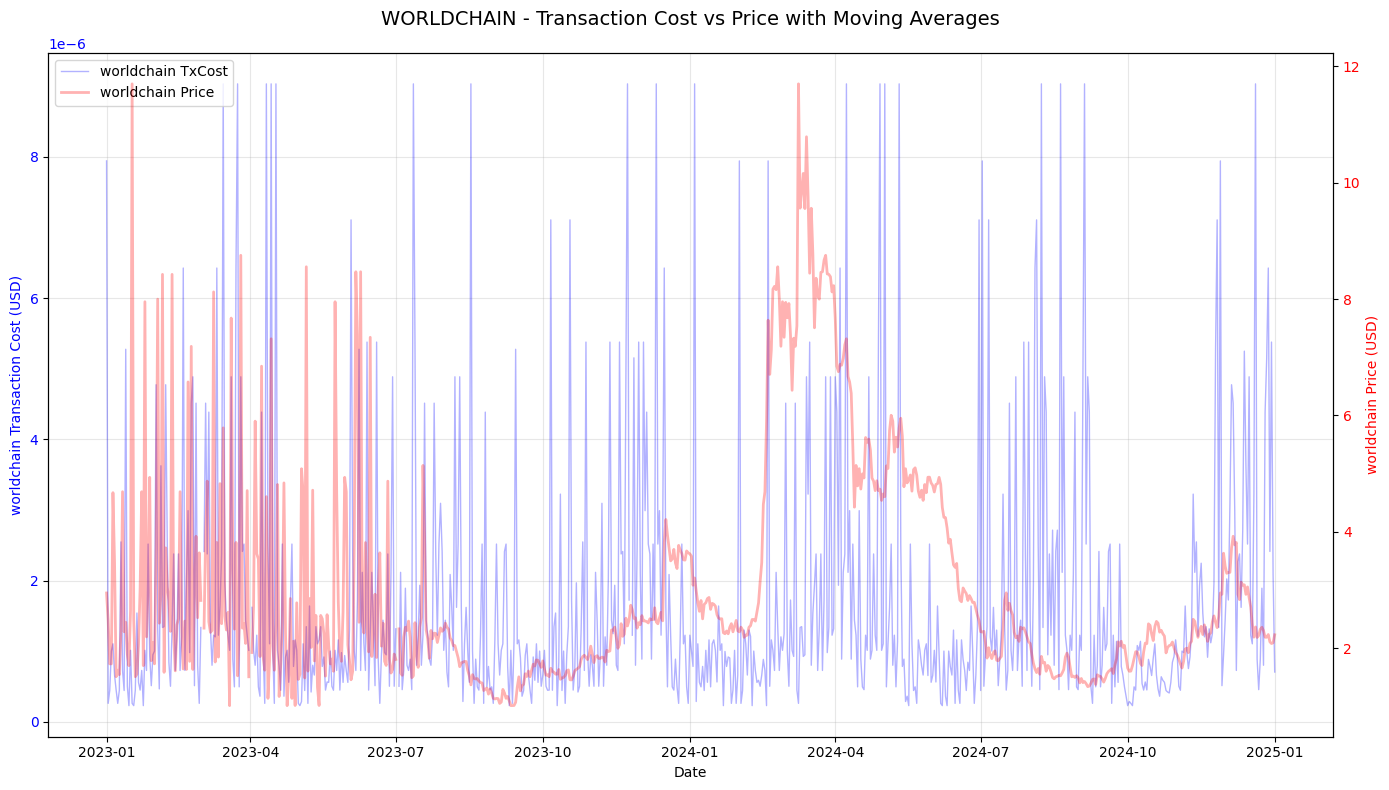

Completed visualization for worldchain


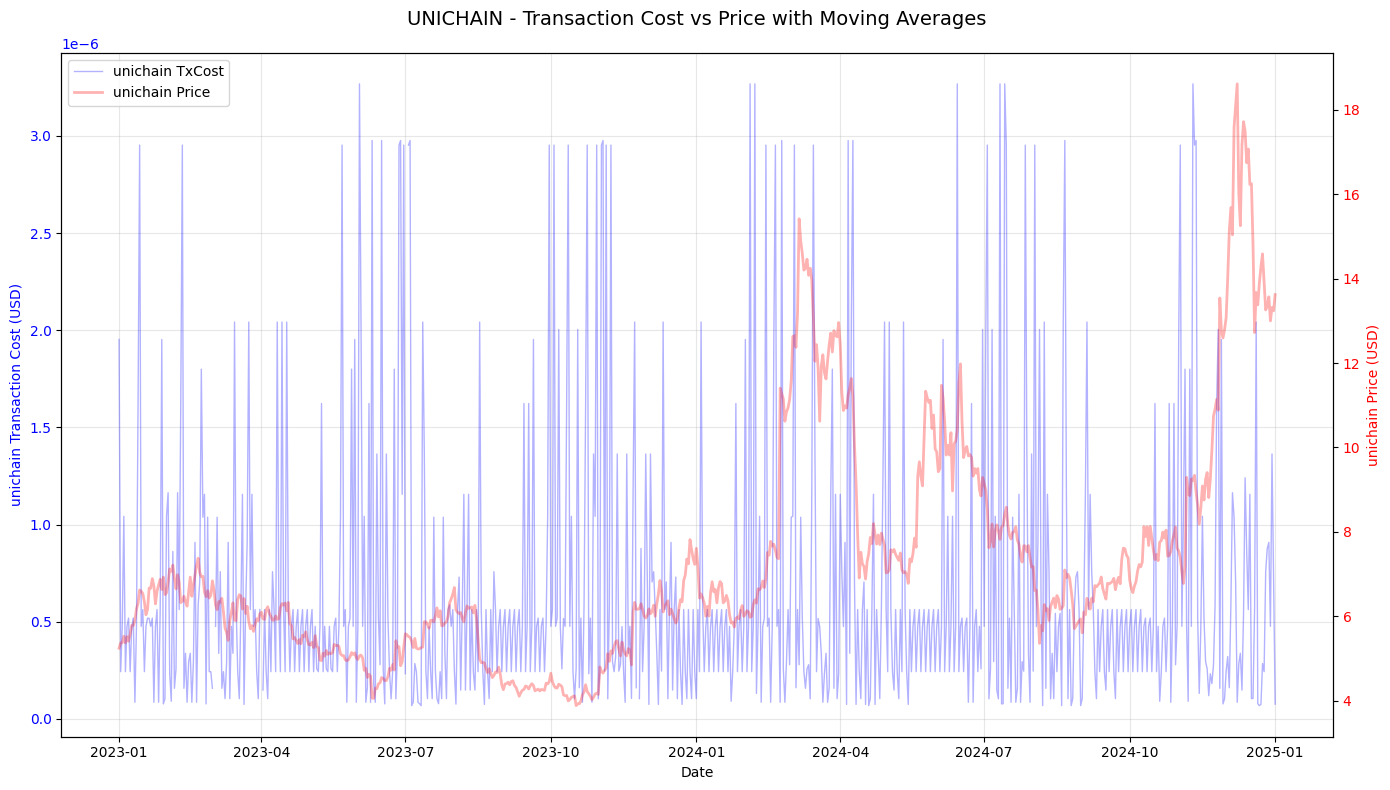

Completed visualization for unichain


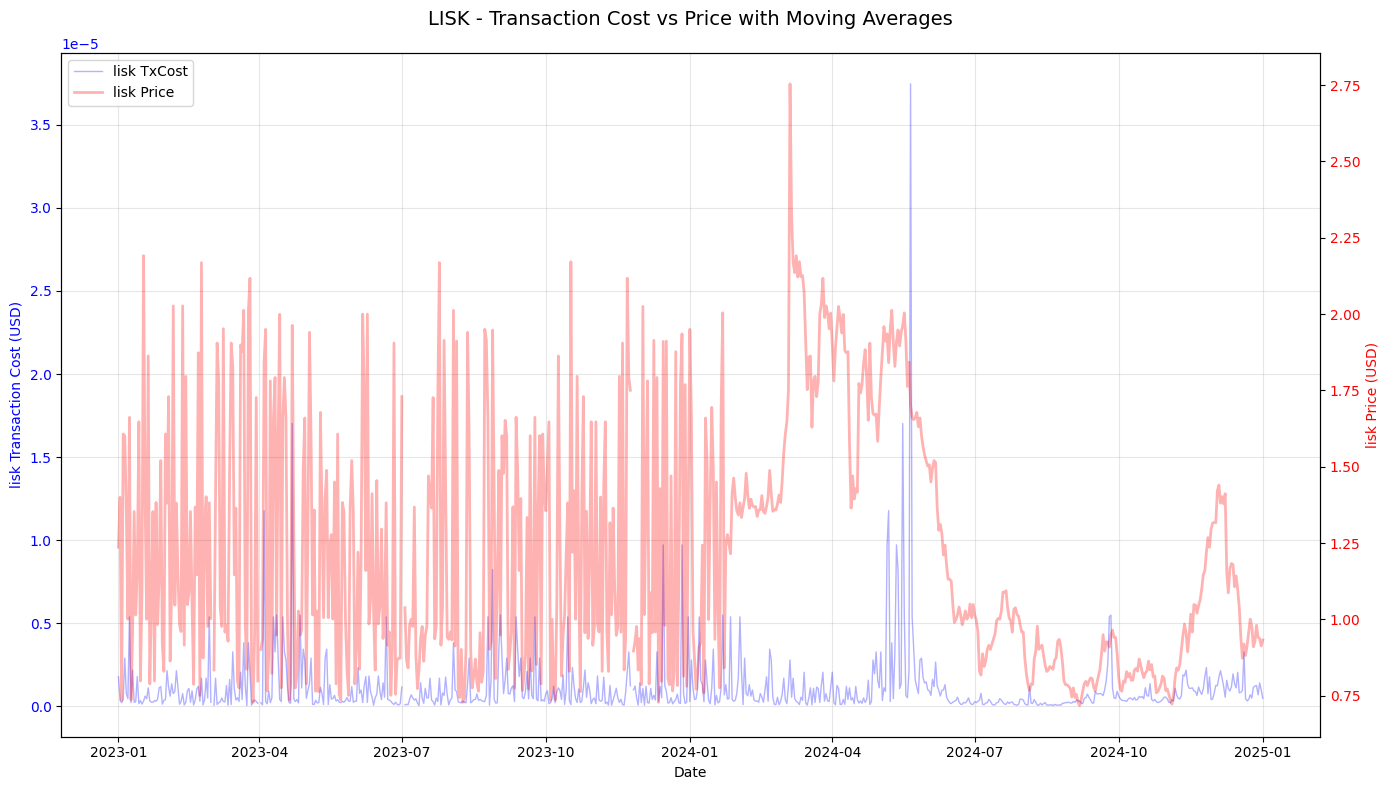

Completed visualization for lisk


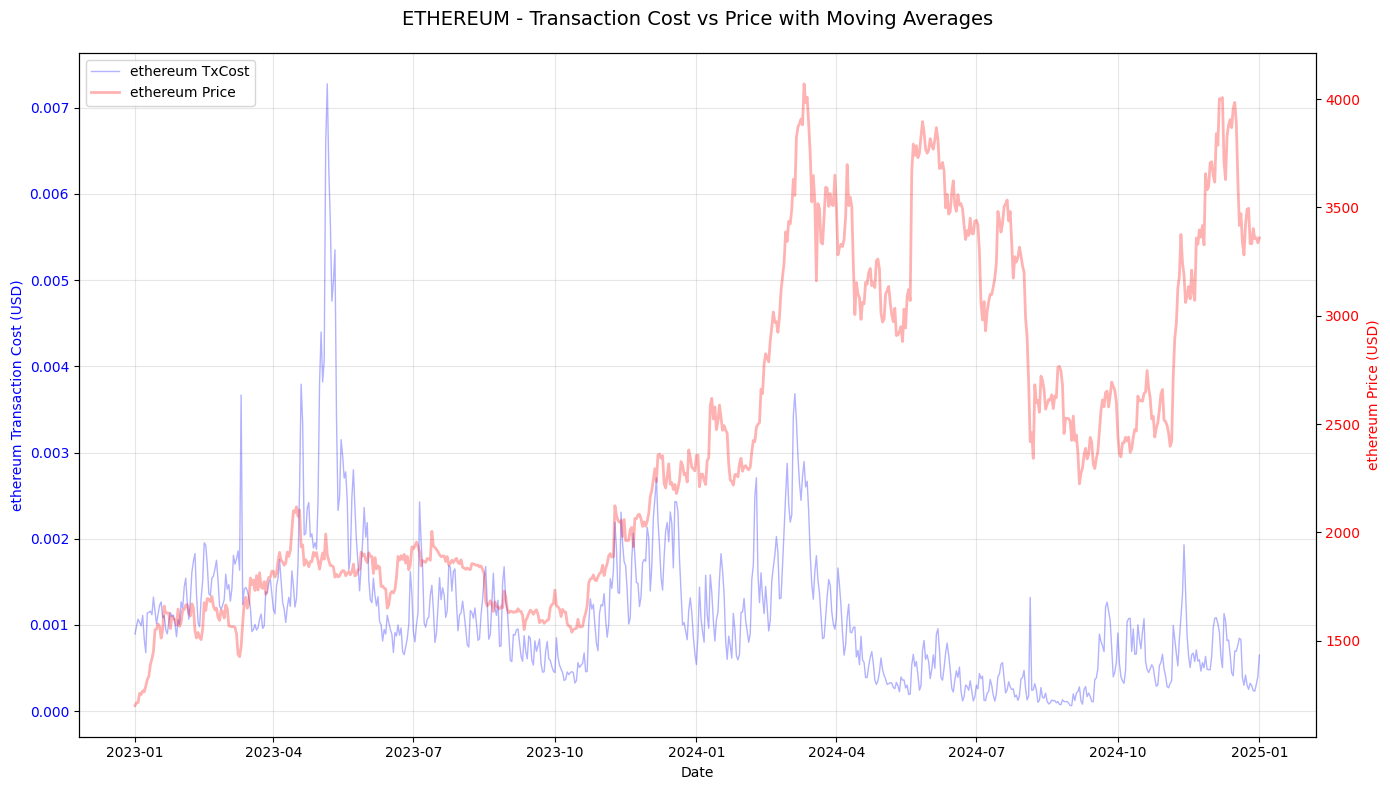

Completed visualization for ethereum


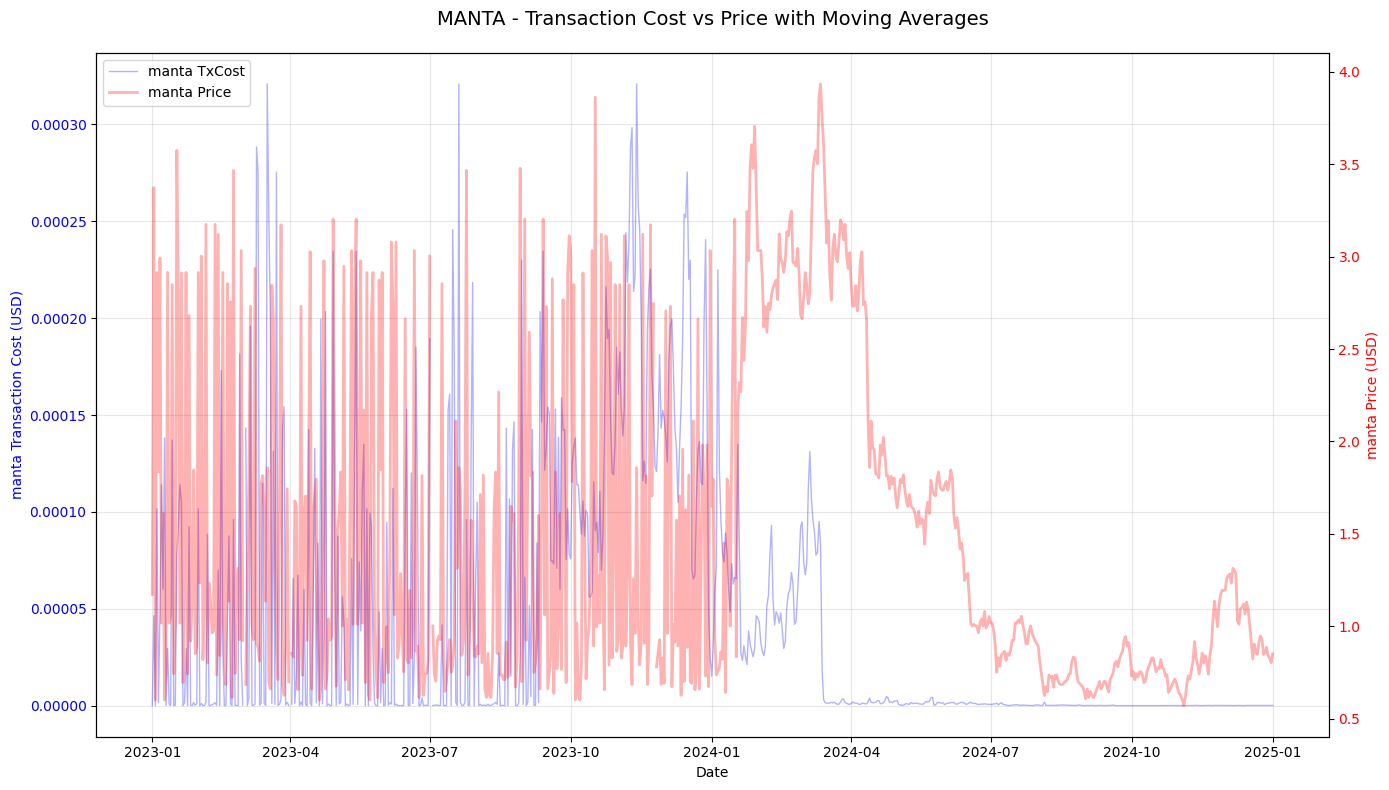

Completed visualization for manta


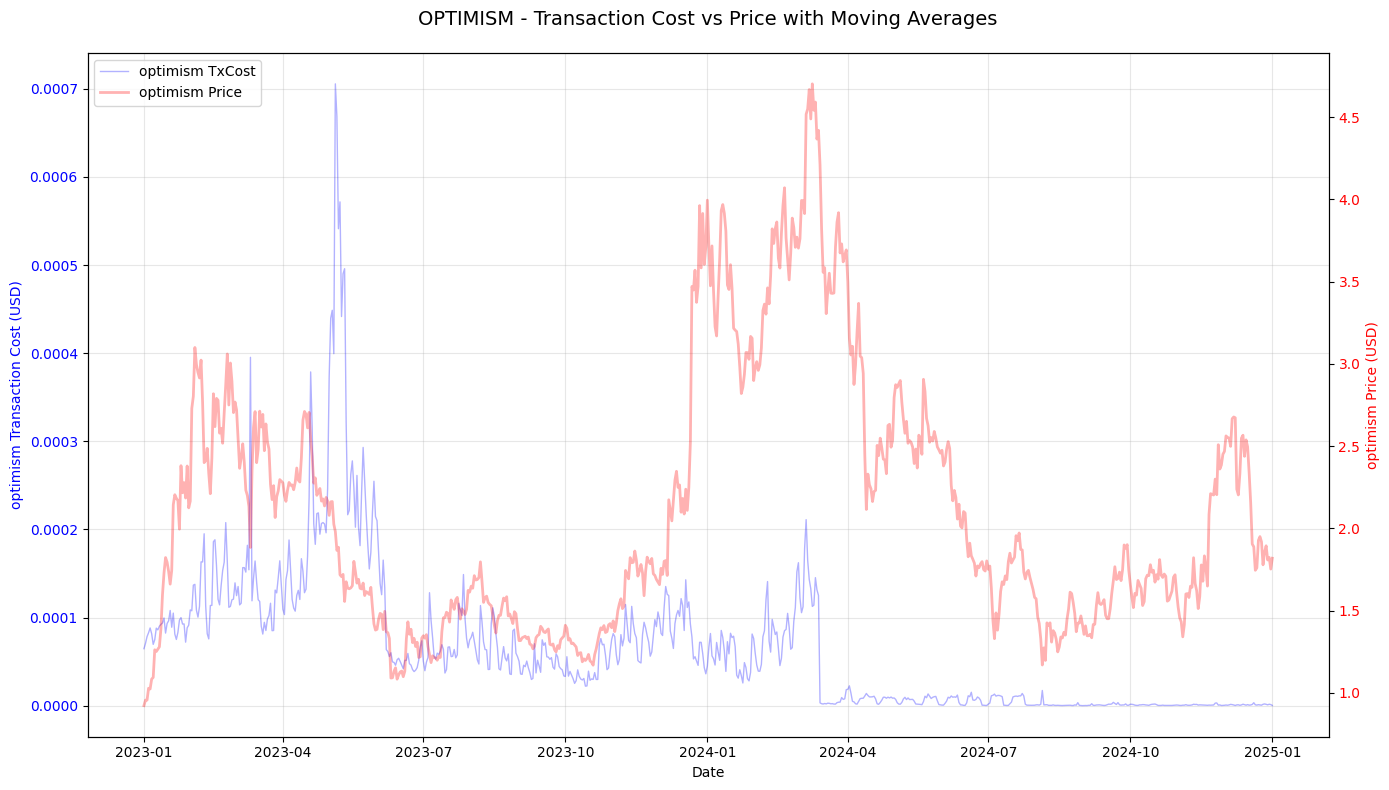

Completed visualization for optimism


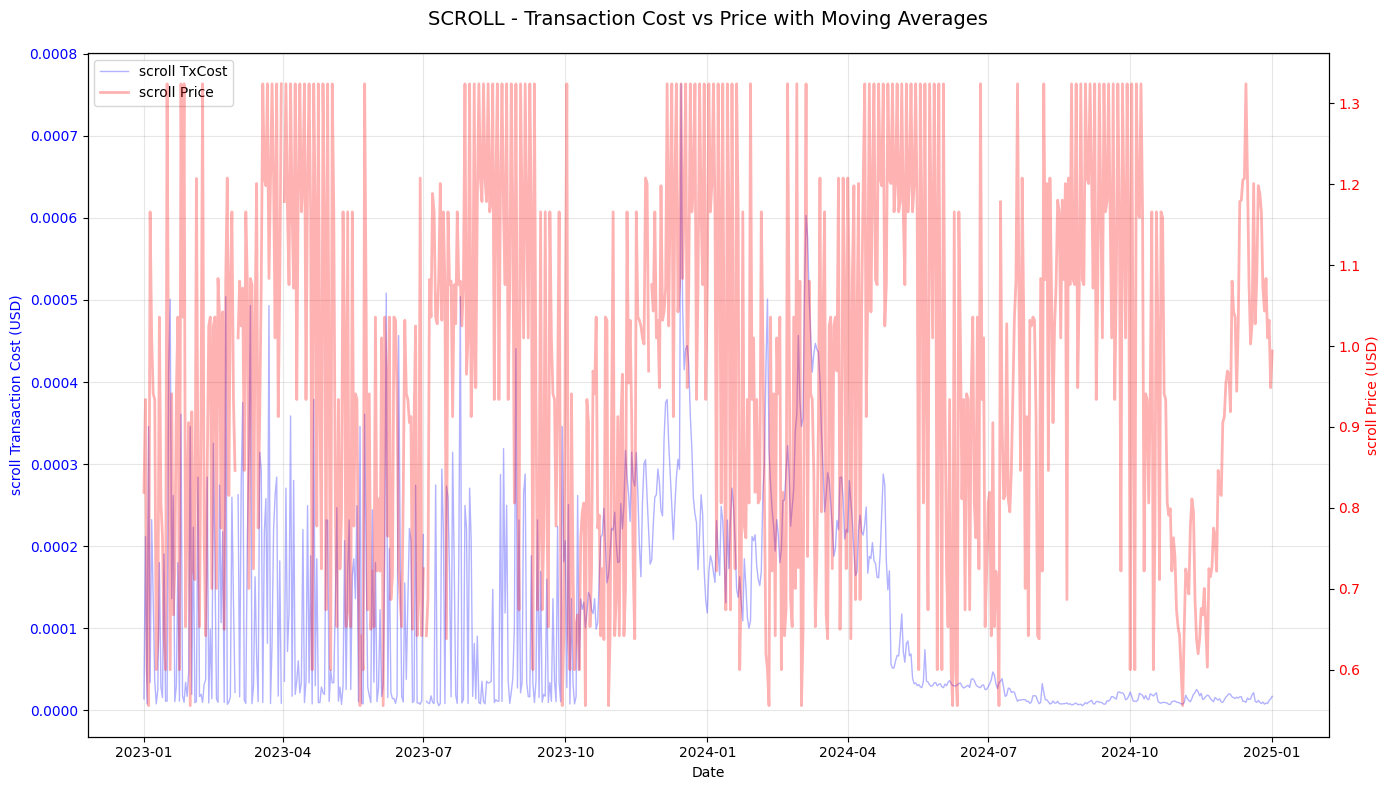

Completed visualization for scroll


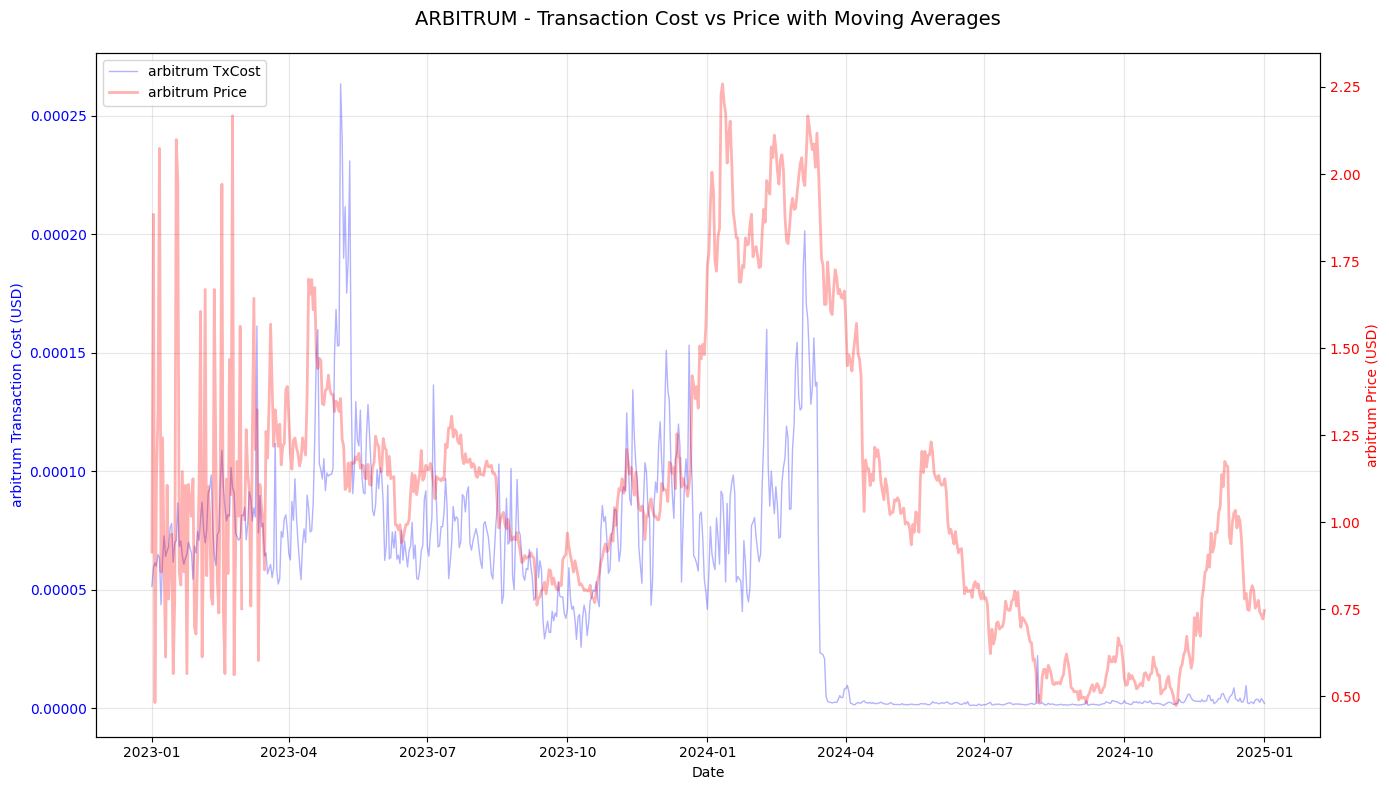

Completed visualization for arbitrum


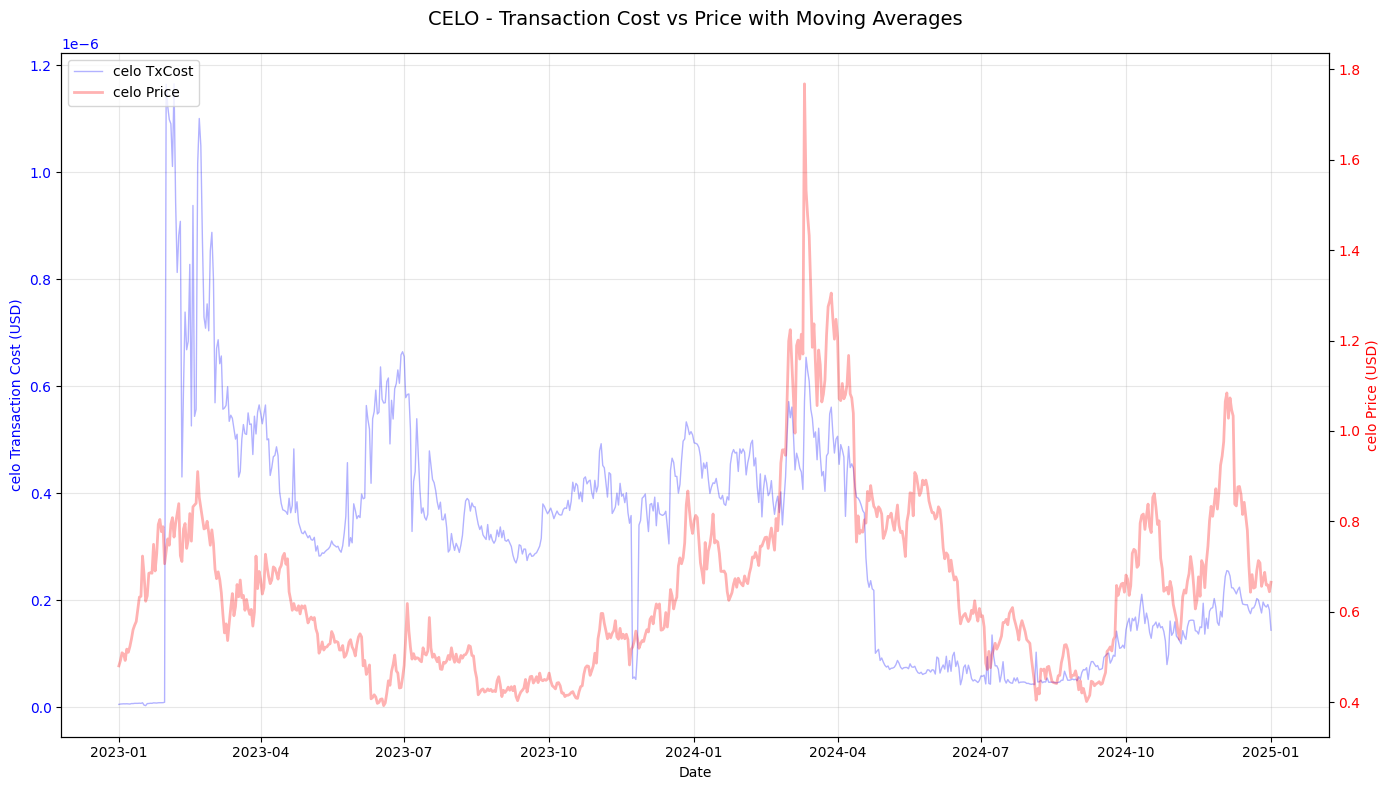

Completed visualization for celo


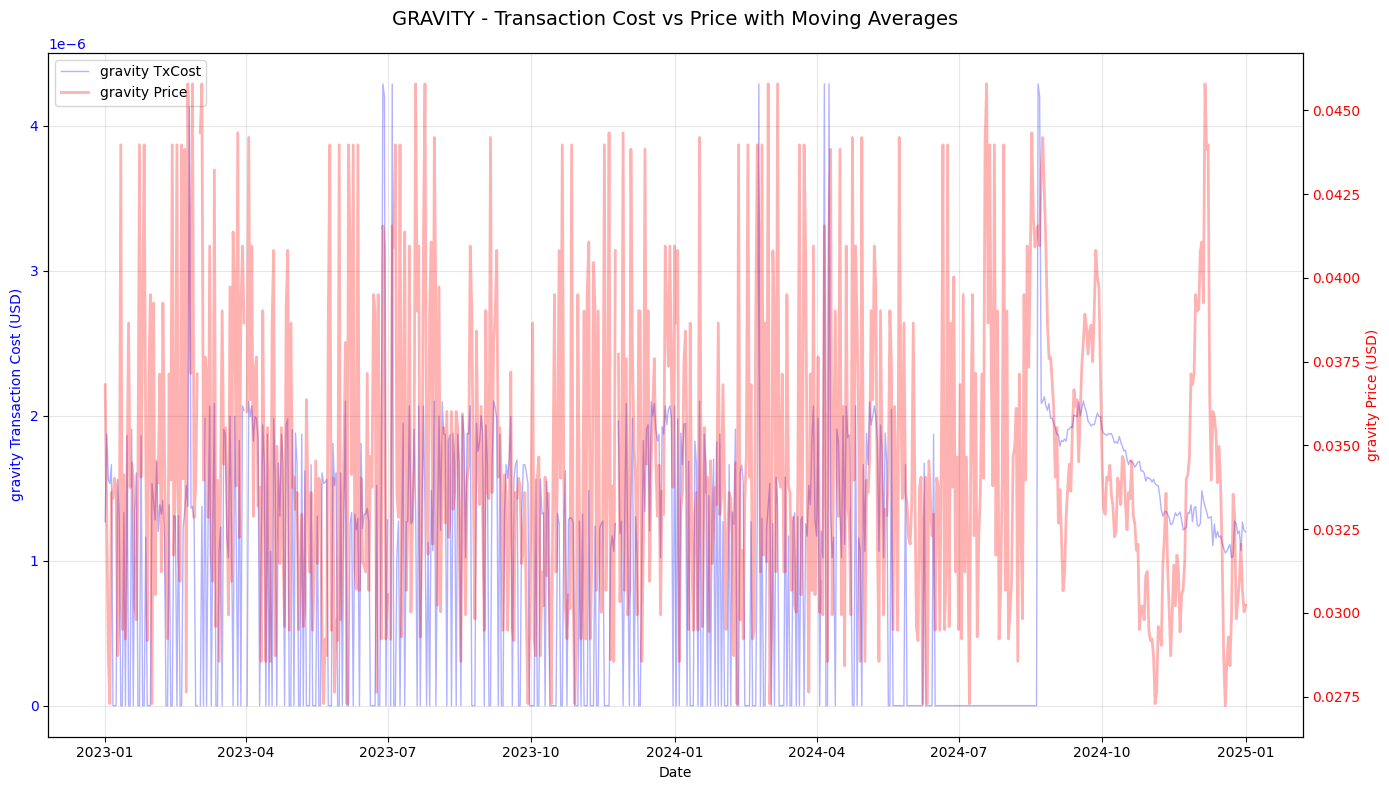

Completed visualization for gravity


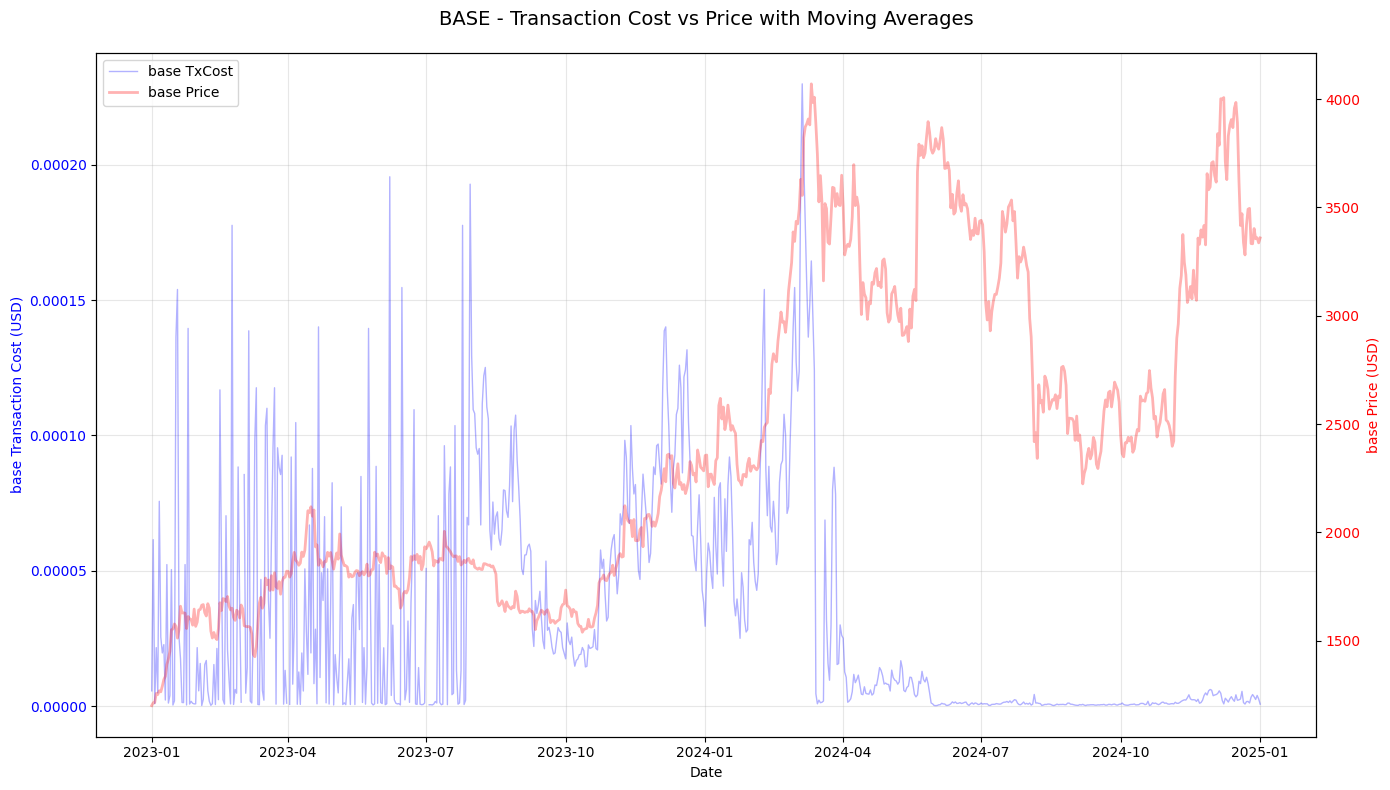

Completed visualization for base


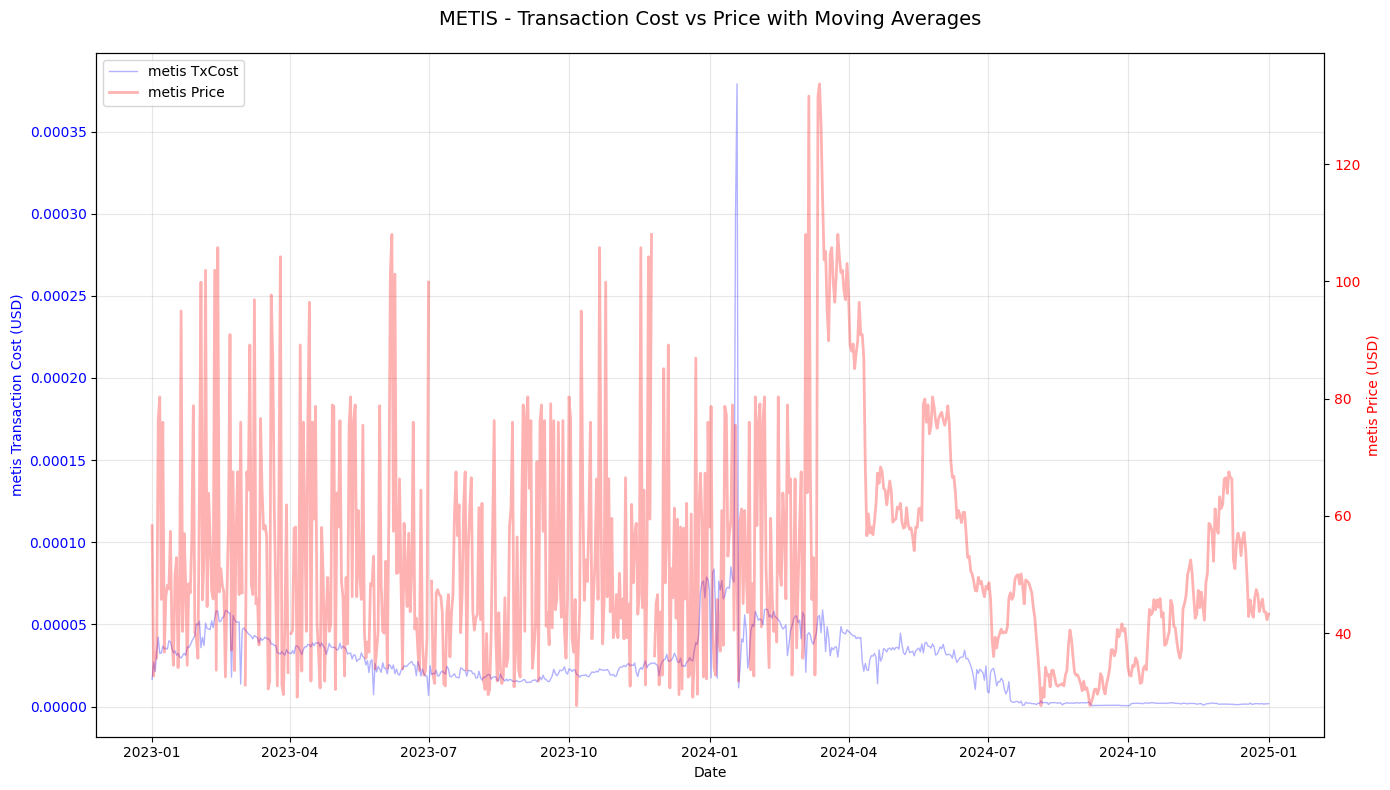

Completed visualization for metis


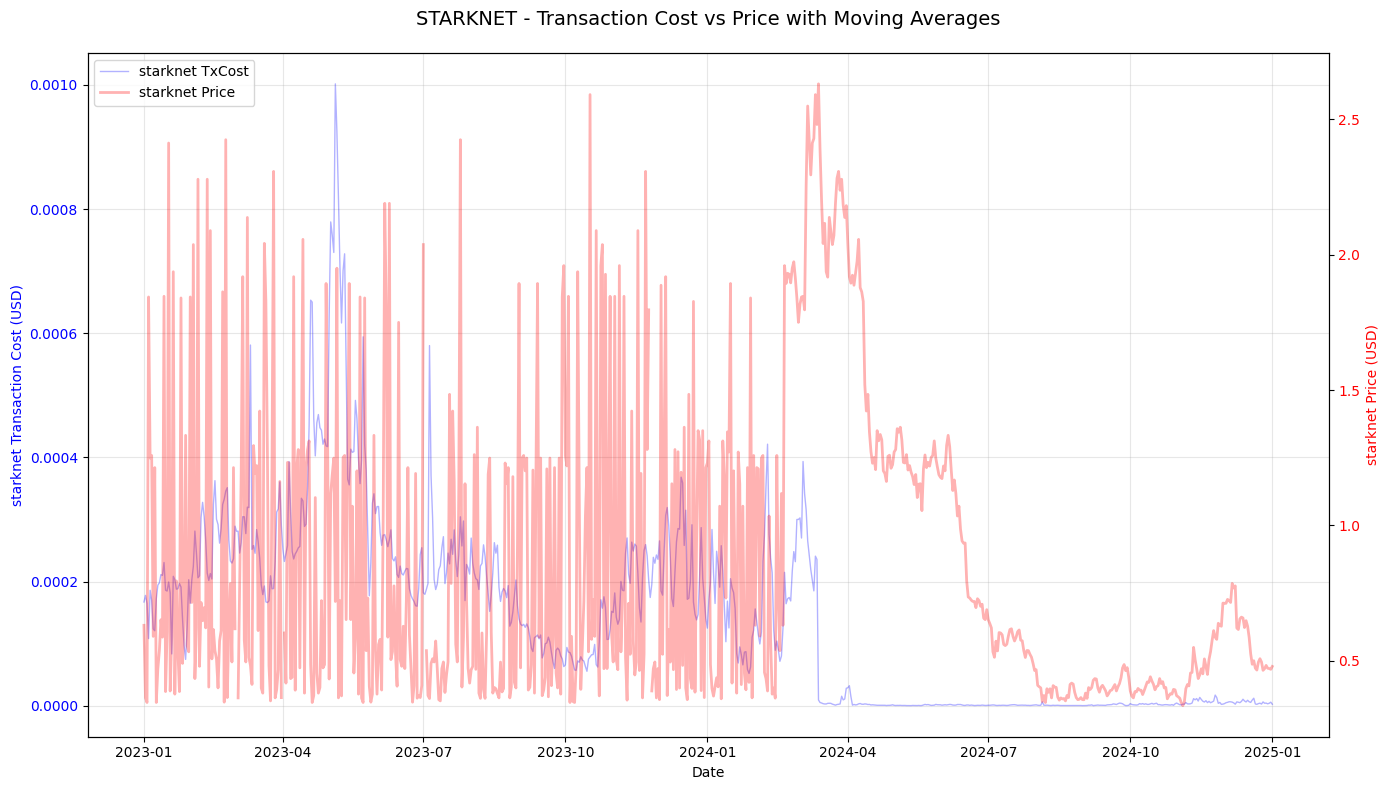

Completed visualization for starknet


In [51]:
filtered_data_metric = filtered_data_metric.fill_null(strategy="forward")
filtered_data_price = filtered_data_price.fill_null(strategy="forward")

for coin in common_prefixes:
    metric_col = f"{coin}_txcosts_median_eth"
    price_col = f"{coin}_price"

    # 添加指数移动平均
    metric_series = filtered_data_metric.select(
        "date", 
        pl.col(metric_col),
        # pl.col(metric_col).ewm_mean(span=60).alias(f"{metric_col}_ema")  # 30天指数移动平均
    )
    
    price_series = filtered_data_price.select(
        "date", 
        pl.col(price_col)
    )
    
    # 合并数据
    combined_data = (
        metric_series
        .join(price_series, on="date", how="inner")
        .sort("date")
    )
        
    if len(combined_data) < 30:  # 数据点太少就跳过
        continue
        
    # 创建双轴图
    fig, ax1 = plt.subplots(figsize=(14, 8))
    ax2 = ax1.twinx()
    
    # 提取数据
    dates = combined_data["date"].to_numpy()
    metric_vals = combined_data[metric_col].to_numpy()
    # metric_ema = combined_data[f"{metric_col}_ema"].to_numpy()
    
    price_vals = combined_data[price_col].to_numpy()

    # 左轴：交易成本指标
    line1 = ax1.plot(dates, metric_vals, 'b-', alpha=0.3, linewidth=1, label=f"{coin} TxCost")
    # line2 = ax1.plot(dates, metric_ema, 'b-', alpha=0.7, linewidth=2, label=f"{coin} TxCost EMA")
    
    ax1.set_xlabel("Date")
    ax1.set_ylabel(f"{coin} Transaction Cost (USD)", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # 右轴：价格
    line4 = ax2.plot(dates, price_vals, 'r-', alpha=0.3, linewidth=2, label=f"{coin} Price")

    ax2.set_ylabel(f"{coin} Price (USD)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # 设置标题
    plt.title(f"{coin.upper()} - Transaction Cost vs Price with Moving Averages", fontsize=14, pad=20)
    
    # 网格
    ax1.grid(True, alpha=0.3)
    
    # 合并图例
    lines = line1 + line4 
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 1))
    
    # 旋转日期标签以避免重叠
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f"Completed visualization for {coin}")


Text(0, 0.5, 'ZKSync Era Price (USDT)')

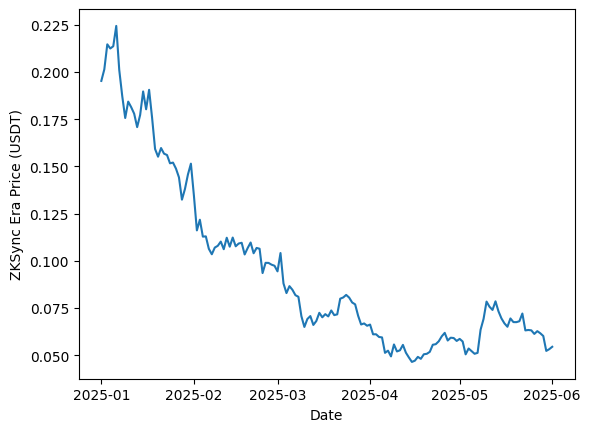

In [52]:
import matplotlib.pyplot as plt

data_for_plot = data.filter(
    pl.col("date").is_between(pl.date(2025, 1, 1), pl.date(2025, 6, 1))
)
data_for_plot = data_for_plot.sort("date")

plt.plot(data_for_plot["date"], data_for_plot["zksyncera_price"])
plt.xlabel("Date")
plt.ylabel("ZKSync Era Price (USDT)")

In [53]:
market_data._api.rest.configuration.base_path

'https://fapi.binance.com'